Import libraries

In [1]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

2026-03-06 23:07:59.185939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772838479.514964      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772838479.612620      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772838480.353261      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772838480.353339      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772838480.353343      55 computation_placer.cc:177] computation placer alr

Data Setup

In [2]:
train_data = '/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/train'
paths = []
labels = []

folders_paths = os.listdir(train_data)

for path in folders_paths:
    folder_path = os.path.join(train_data, path)     
    folder_name = os.listdir(folder_path)
    
    for image in folder_name:
        image_name = os.path.join(folder_path, image)  
        paths.append(image_name)
        labels.append(path)

Aseries = pd.Series(paths, name='Paths')
Bseries = pd.Series(labels, name='Labels')
train = pd.concat([Aseries, Bseries],axis=1)
train

,Paths,Labels
0,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
1,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
2,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
3,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
4,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
...,...,...
246,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
247,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
248,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
249,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid


In [3]:
test_data = '/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test'
paths = []
labels = []

folders_paths = os.listdir(test_data)

for path in folders_paths:
    folder_path = os.path.join(test_data, path)     
    folder_name = os.listdir(folder_path)
    
    for image in folder_name:
        image_name = os.path.join(folder_path, image)  
        paths.append(image_name)
        labels.append(path)

Aseries = pd.Series(paths, name='Paths')
Bseries = pd.Series(labels, name='Labels')
test = pd.concat([Aseries, Bseries],axis=1)
test

,Paths,Labels
0,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
1,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
2,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
3,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
4,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
...,...,...
61,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
62,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
63,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
64,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid


In [5]:
train["Labels"].unique()


array(['Normal', 'Viral Pneumonia', 'Covid'], dtype=object)

In [6]:
classes = train["Labels"].value_counts()
classes

Labels
Covid              111
Normal              70
Viral Pneumonia     70
Name: count, dtype: int64

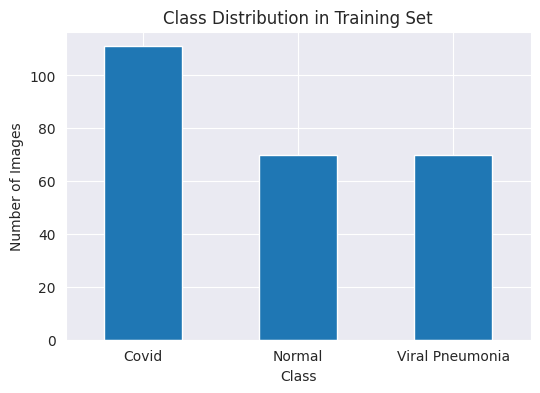

In [7]:
plt.figure(figsize=(6,4))
classes.plot(kind='bar')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

Preprocessing

In [8]:
test1,valid = train_test_split(test, train_size=0.5,shuffle= True , random_state=43)

In [9]:
test1

,Paths,Labels
28,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
42,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
56,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
9,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
10,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
32,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
24,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
12,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
36,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
4,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal


In [10]:
valid

,Paths,Labels
26,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
5,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
48,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
40,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
22,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
65,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
33,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
19,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
14,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
59,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid


In [11]:
img_size=(224,224)
batch_size= 16
tr_gen = ImageDataGenerator()
val_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()
train_gen = tr_gen.flow_from_dataframe(train,
                                      x_col='Paths',
                                      y_col='Labels',
                                      target_size=img_size,
                                      class_mode='categorical',
                                      color_mode='rgb',
                                      batch_size=batch_size,
                                      shuffle=True)
valid_gen = val_gen.flow_from_dataframe(valid,
                                      x_col='Paths',
                                      y_col='Labels',
                                      target_size=img_size,
                                      class_mode='categorical',
                                      color_mode='rgb',
                                      batch_size=batch_size,
                                      shuffle=True)
test_gen = ts_gen.flow_from_dataframe(test,
                                      x_col='Paths',
                                      y_col='Labels',
                                      target_size=img_size,
                                      class_mode='categorical',
                                      color_mode='rgb',
                                      batch_size=batch_size,
                                      shuffle=False)

Found 251 validated image filenames belonging to 3 classes.
Found 33 validated image filenames belonging to 3 classes.
Found 66 validated image filenames belonging to 3 classes.


Sample from Train model

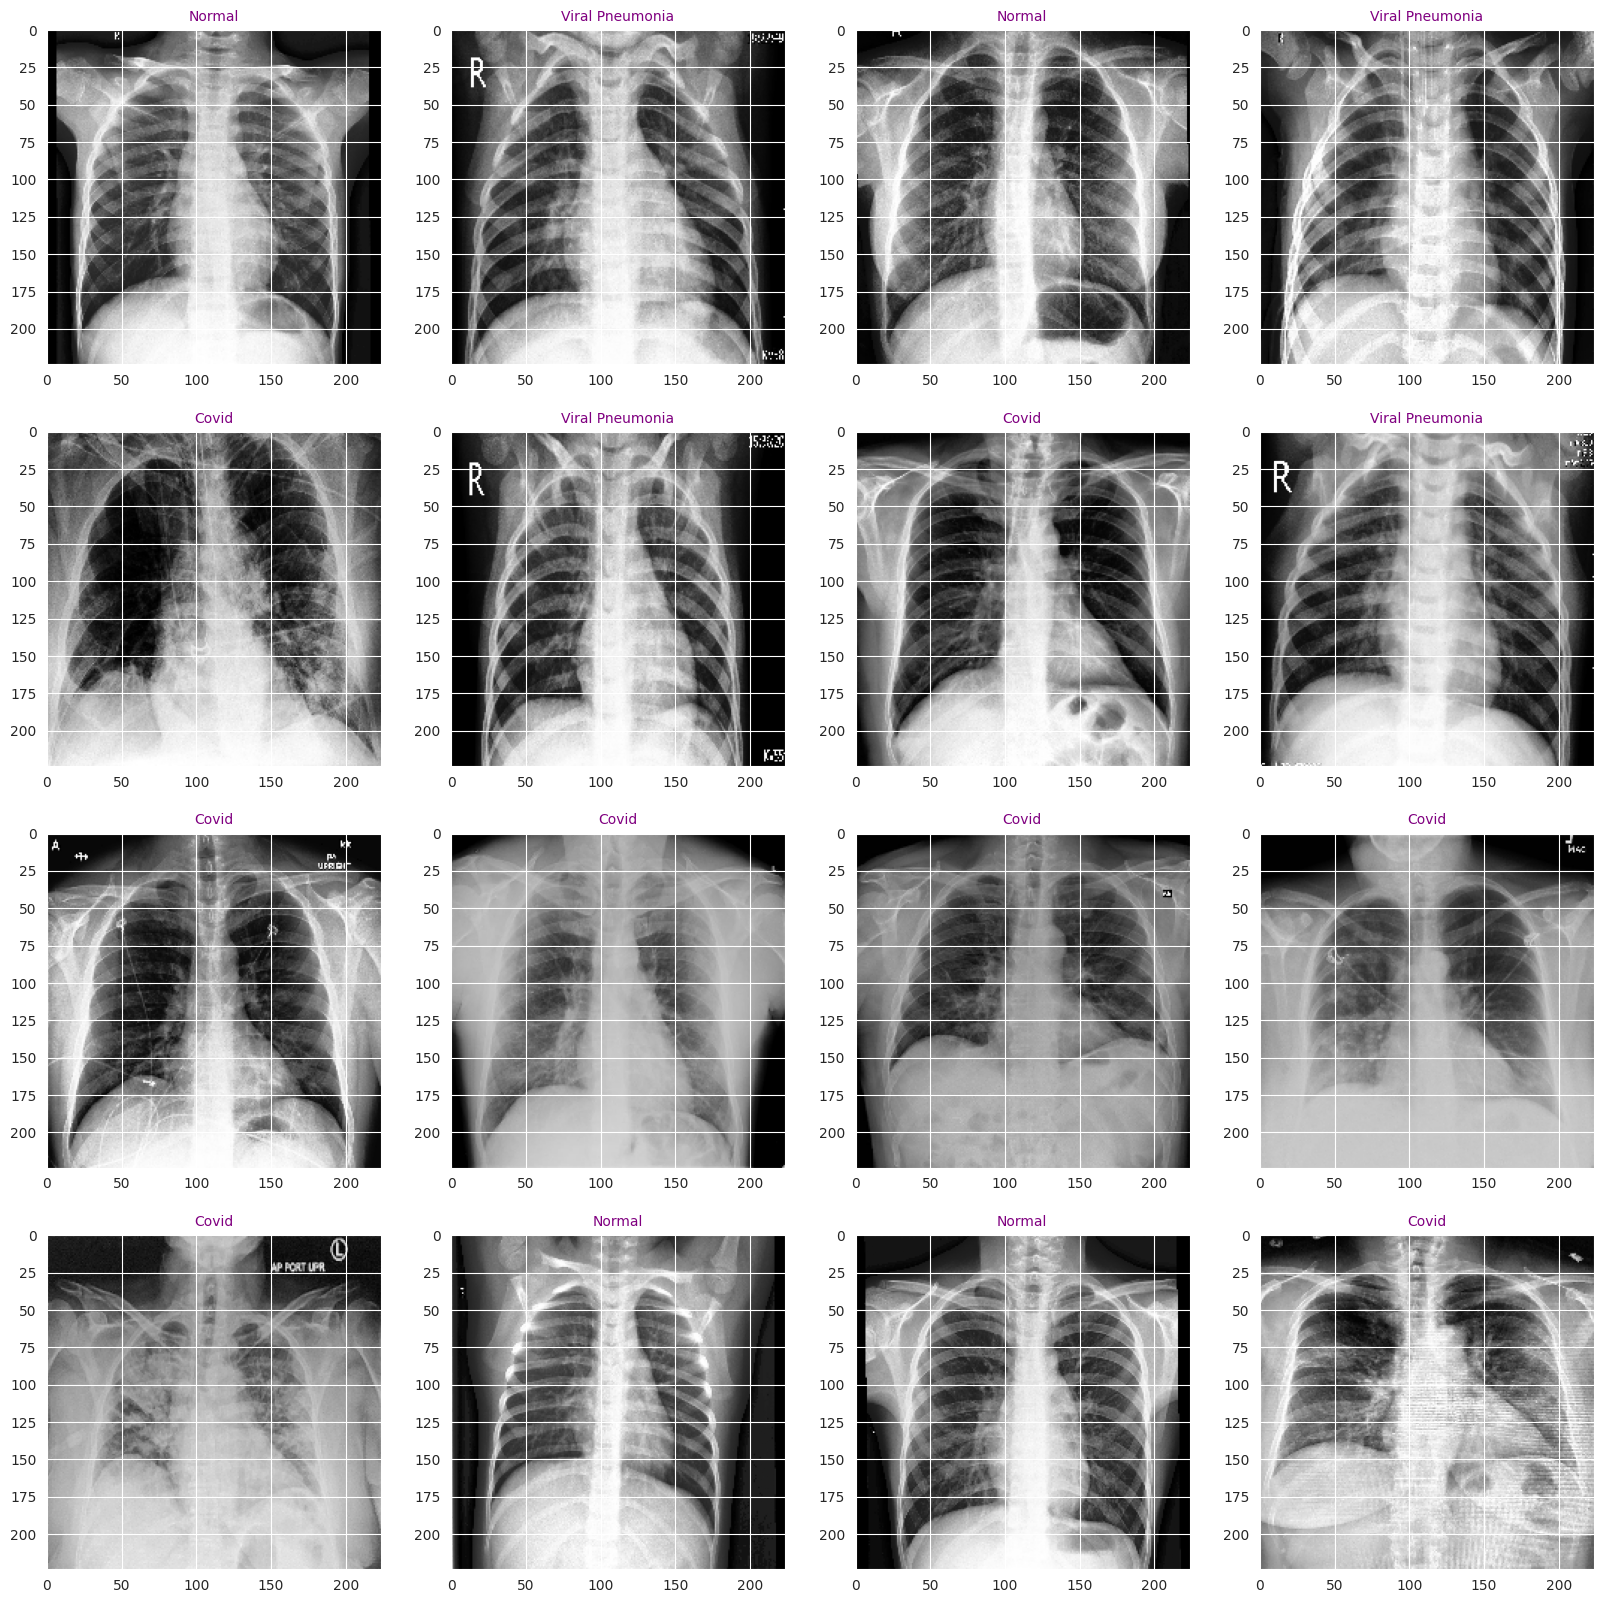

In [12]:
T_dect = train_gen.class_indices
classes = list(T_dect.keys())
images , labels = next(train_gen)

plt.figure(figsize=(20,20))
for i in range(16):
    plt.subplot(4,4,i+1)
    image = images[i]/255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color = 'purple', fontsize= 10)
    

Model Training

In [13]:
img_shape = (img_size[0], img_size[1] , 3)
Num_class= len(classes)
base_model=tf.keras.applications.VGG16(include_top=False,weights=None,input_shape=img_shape,pooling='max')
base_model.load_weights('/kaggle/input/datasets/omarmahmouud/vggweight/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5')

#Freeze convolutional layers
for layer in base_model.layers:
    layer.trainable = False
    
model_VGG16 = Sequential([
    base_model,
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(Num_class, activation='softmax')
])

model_VGG16.compile(
    optimizer=Adamax(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_VGG16.summary()

2026-03-06 23:12:40.358392: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,835 (56.64 MB)

 Trainable params: 133,123 (520.01 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [15]:
history_VGG16=model_VGG16.fit(x=train_gen,epochs=15,verbose=1,validation_data=valid_gen,validation_steps=None,shuffle=False)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 76s 5s/step - accuracy: 0.5555 - loss: 1.0622 - val_accuracy: 0.3030 - val_loss: 12.5655
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.8270 - loss: 0.5158 - val_accuracy: 0.3636 - val_loss: 6.2921
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.9224 - loss: 0.2233 - val_accuracy: 0.3939 - val_loss: 4.1612
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.9527 - loss: 0.1702 - val_accuracy: 0.4242 - val_loss: 3.0107
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 84s 5s/step - accuracy: 0.9117 - loss: 0.2139 - val_accuracy: 0.4242 - val_loss: 2.1182
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.9613 - loss: 0.1222 - val_accuracy: 0.4545 - val_loss: 1.6107
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.9803 - loss: 0.1269 - val_accuracy: 0.5455 - val_loss: 1.2665
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.9901 - loss: 0.0851 - val_accuracy: 0.6061 - val_loss

Model Evaluation

In [16]:
train_VGG16_acc=history_VGG16.history['accuracy']
train_VGG16_loss=history_VGG16.history['loss']
val_VGG16_acc=history_VGG16.history['val_accuracy']
val_VGG16_loss=history_VGG16.history['val_loss']
index_VGG16_loss=np.argmin(val_VGG16_loss)
val_VGG16_lowest=val_VGG16_loss[index_VGG16_loss]
index_VGG16_acc=np.argmin(val_VGG16_acc)
val_VGG16_highest=val_VGG16_acc[index_VGG16_acc]
Epochs_VGG16=[i+1 for i in range(len(train_VGG16_acc))]
loss_label_VGG16=f'best epochs={str(index_VGG16_loss +1)}'
acc_label_VGG16=f'best epochs={str(index_VGG16_acc +1)}'

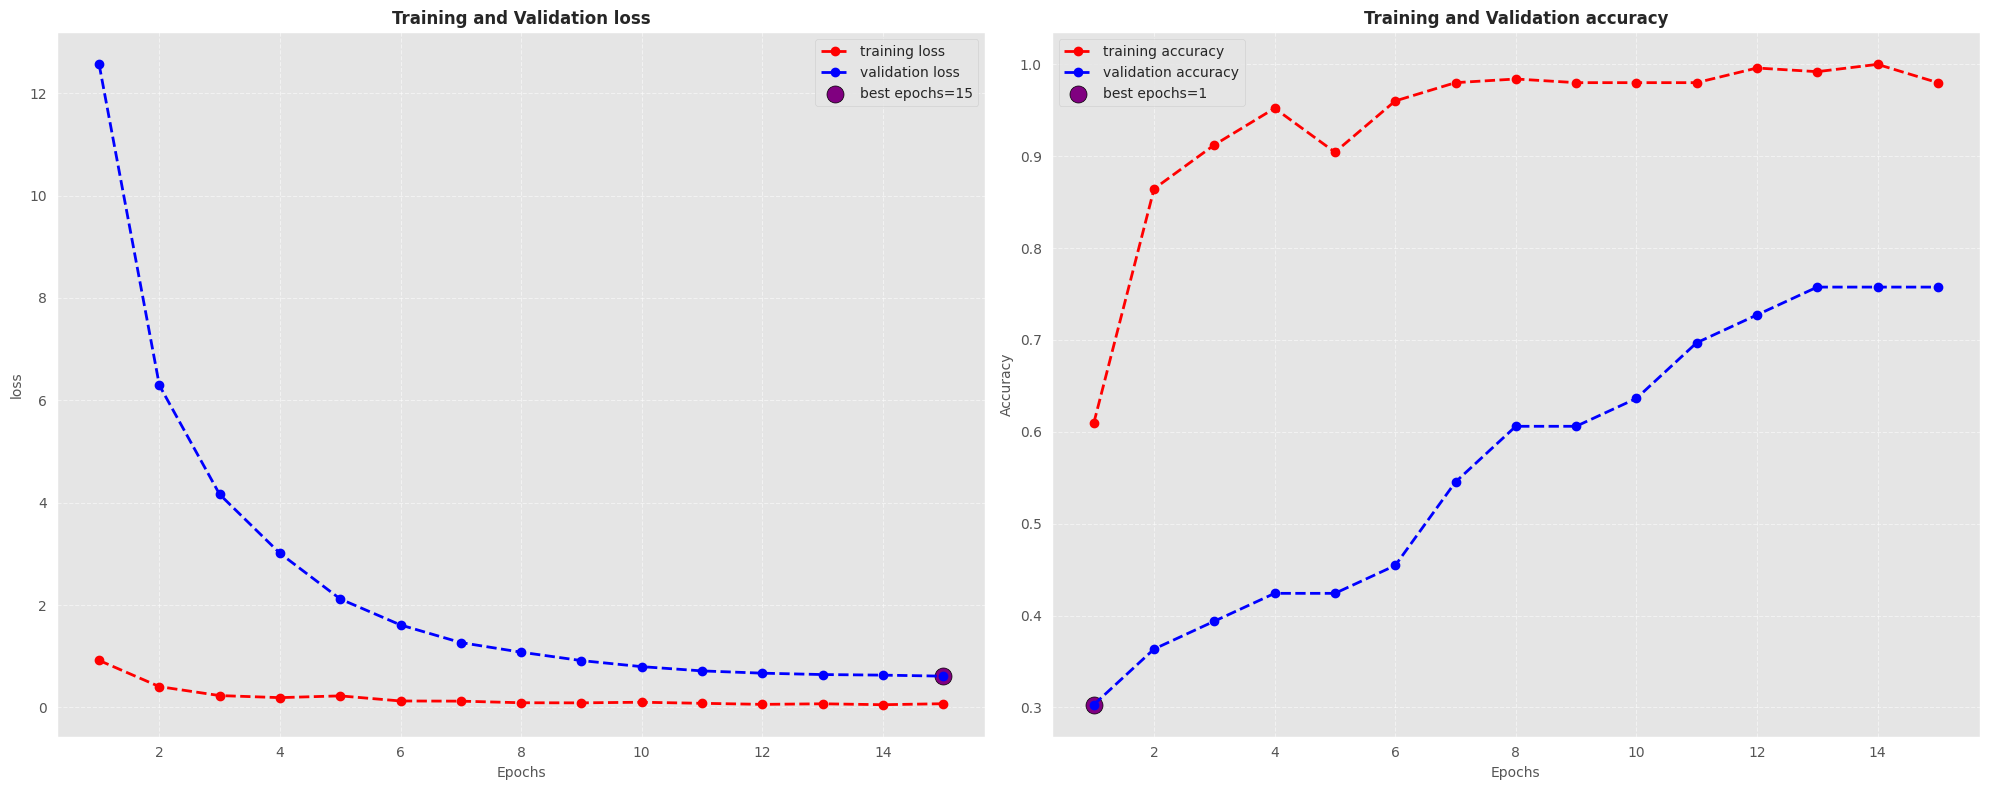

In [18]:
plt.figure(figsize=(20,8))
plt.style.use("ggplot")

#accuracy plot
plt.subplot(1,2,2)
plt.plot(Epochs_VGG16,train_VGG16_acc,'r--',linewidth=2,marker='o',label='training accuracy')
plt.plot(Epochs_VGG16,val_VGG16_acc,'b--',linewidth=2,marker='o',label='validation accuracy')
plt.scatter(index_VGG16_acc +1 ,val_VGG16_highest , s=150 , c='purple', edgecolors='black',label=acc_label_VGG16)
plt.title("Training and Validation accuracy",fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=10)
plt.ylabel('Accuracy',fontsize=10)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)

#loss plot
plt.subplot(1,2,1)
plt.plot(Epochs_VGG16,train_VGG16_loss,'r--',linewidth=2,marker='o',label='training loss')
plt.plot(Epochs_VGG16,val_VGG16_loss,'b--',linewidth=2,marker='o',label='validation loss')
plt.scatter(index_VGG16_loss +1 ,val_VGG16_lowest , s=150 , c='purple', edgecolors='black',label=loss_label_VGG16)
plt.title("Training and Validation loss",fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=10)
plt.ylabel('loss',fontsize=10)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)

plt.tight_layout()
plt.show()

In [20]:
train_VGG16_score=model_VGG16.evaluate(train_gen, steps=16, verbose=1)
val_VGG16_score=model_VGG16.evaluate(valid_gen, steps=16, verbose=1)
test_VGG16_score=model_VGG16.evaluate(test_gen, steps=16, verbose=1)
print("train loss",train_VGG16_score[0])
print("train accuracy",train_VGG16_score[1])
print('-'* 20)
print("val loss",val_VGG16_score[0])
print("val accuracy",val_VGG16_score[1])
print('-'* 20)
print("test loss",test_VGG16_score[0])
print("test accuracy",test_VGG16_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.9957 - loss: 0.0239
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.7566 - loss: 0.6194
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 808ms/step - accuracy: 0.8298 - loss: 0.4661
train loss 0.023692481219768524
train accuracy 0.9960159659385681
--------------------
val loss 0.6103812456130981
val accuracy 0.7575757503509521
--------------------
test loss 0.4545043110847473
test accuracy 0.8333333134651184


Confusion Matrix

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step


<function matplotlib.pyplot.show(close=None, block=None)>

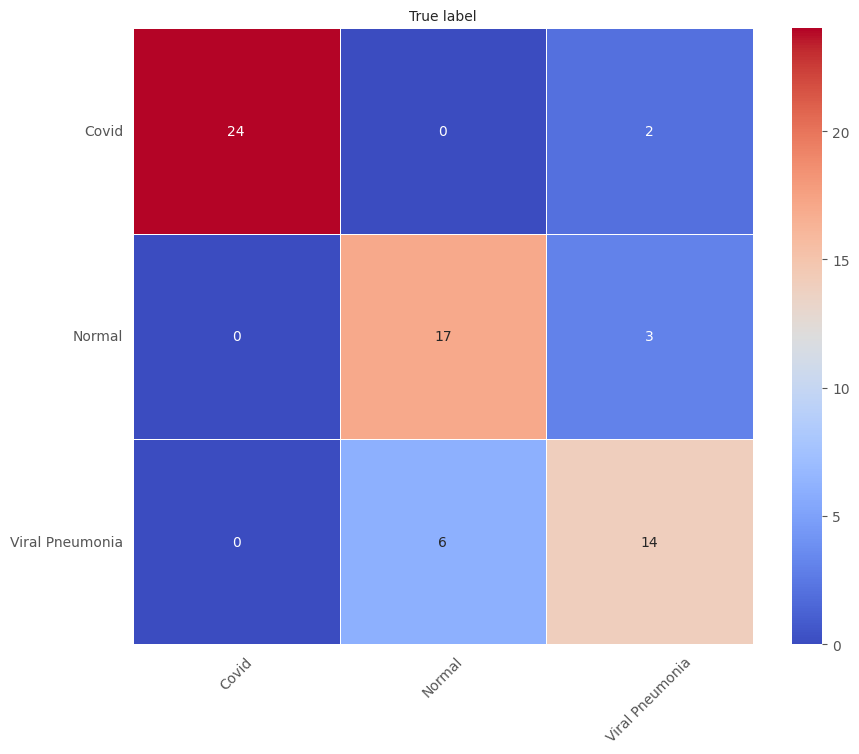

In [22]:
preds_VGG16= model_VGG16.predict(test_gen)
y_pred_VGG16= np.argmax(preds_VGG16,axis=1)
#class labels
g_VGG16_dict=test_gen.class_indices
classes=list(g_VGG16_dict.keys())

#confusion matrix
cm_VGG16= confusion_matrix(test_gen.classes, y_pred_VGG16)
plt.figure(figsize=(10,8))
sns.heatmap(cm_VGG16,annot= True, fmt='d',cmap='coolwarm', xticklabels=classes, yticklabels= classes, linewidths=0.5)
plt.title("Confusion matrix", fontsize=12)
plt.title("Predicted label", fontsize=10)
plt.title("True label", fontsize=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show

Save Model

In [23]:
model_VGG16.save('model_VGG16.keras')